In [1]:
!pip install requests pandas matplotlib

In [ ]:
from dotenv import load_dotenv
import os
import requests

load_dotenv()

API_KEY = os.getenv("API_KEY")
city = "Hyderabad"

url = f"https://api.openweathermap.org/data/2.5/forecast?q={city}&appid={API_KEY}&units=metric"

response = requests.get(url)
data = response.json()

In [33]:
print(data)

{'cod': '200', 'message': 0, 'cnt': 40, 'list': [{'dt': 1775574000, 'main': {'temp': 31.05, 'feels_like': 29.32, 'temp_min': 28.96, 'temp_max': 31.05, 'pressure': 1008, 'sea_level': 1008, 'grnd_level': 913, 'humidity': 24, 'temp_kf': 2.09}, 'weather': [{'id': 800, 'main': 'Clear', 'description': 'clear sky', 'icon': '01n'}], 'clouds': {'all': 4}, 'wind': {'speed': 3.8, 'deg': 359, 'gust': 7.82}, 'visibility': 10000, 'pop': 0, 'sys': {'pod': 'n'}, 'dt_txt': '2026-04-07 15:00:00'}, {'dt': 1775584800, 'main': {'temp': 27.86, 'feels_like': 26.65, 'temp_min': 25.74, 'temp_max': 27.86, 'pressure': 1010, 'sea_level': 1010, 'grnd_level': 915, 'humidity': 20, 'temp_kf': 2.12}, 'weather': [{'id': 800, 'main': 'Clear', 'description': 'clear sky', 'icon': '01n'}], 'clouds': {'all': 3}, 'wind': {'speed': 2.86, 'deg': 169, 'gust': 3.36}, 'visibility': 10000, 'pop': 0, 'sys': {'pod': 'n'}, 'dt_txt': '2026-04-07 18:00:00'}, {'dt': 1775595600, 'main': {'temp': 24.4, 'feels_like': 23.47, 'temp_min': 24.

In [34]:
# Safe check
if 'list' in data:
    records = []

    for item in data['list']:
        records.append({
            'datetime': item['dt_txt'],
            'temperature': item['main']['temp'],
            'humidity': item['main']['humidity']
        })

    df = pd.DataFrame(records)
    print(df.head())

else:
    print("❌ API Error:", data)

              datetime  temperature  humidity
0  2026-04-07 15:00:00        31.05        24
1  2026-04-07 18:00:00        27.86        20
2  2026-04-07 21:00:00        24.40        22
3  2026-04-08 00:00:00        22.49        33
4  2026-04-08 03:00:00        26.79        27


In [36]:
df['datetime'] = pd.to_datetime(df['datetime'])

df.drop_duplicates(inplace=True)

df.sort_values('datetime', inplace=True)

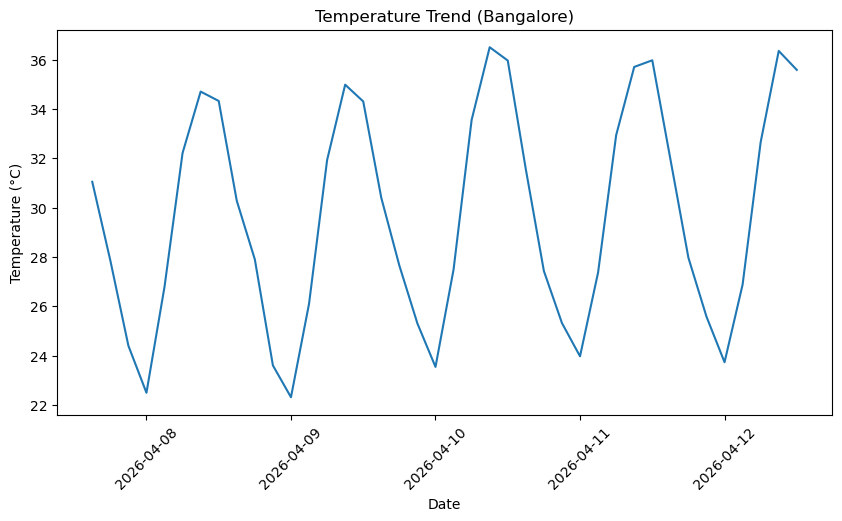

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df['datetime'], df['temperature'])

plt.title("Temperature Trend (Bangalore)")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.xticks(rotation=45)

plt.show()

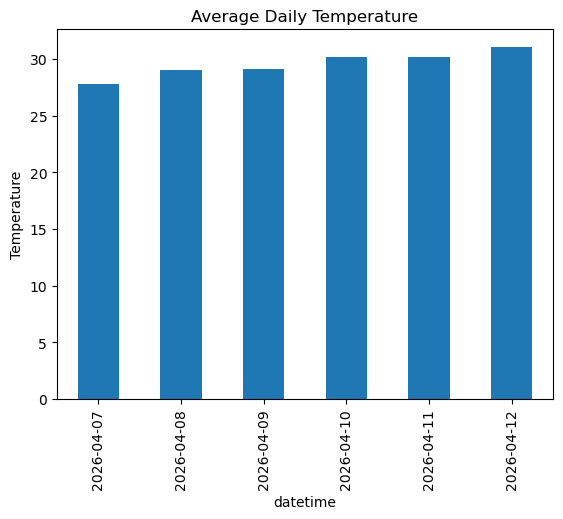

In [38]:
df.groupby(df['datetime'].dt.date)['temperature'].mean().plot(kind='bar')

plt.title("Average Daily Temperature")
plt.ylabel("Temperature")
plt.show()

In [39]:
df.to_csv("weather_data.csv", index=False)